# Dataset Size Experiments: Figure 5

This notebook reproduces report Figure 5. The `ICLR-minimal-dataset` W&B tag groups the finite-data runs and the online-data comparison used to show how sample size changes the learned effective context.


In [1]:
from analysis.utils import REPORT_HEAD_COLORS, REPORT_LINEWIDTH, differing_config, fetch_runs, get_runs_data, style_report_axis
from matplotlib import cycler
from matplotlib.ticker import MultipleLocator
import matplotlib.pyplot as plt
import numpy as np


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
runs = fetch_runs(tags_any=["ICLR-minimal-dataset"])
df = get_runs_data(
    runs,
    metrics=[
        "val_loss",
        "teacher_val_loss",
        "val_best",
        "kl_div_unigram_learned_val",
        "kl_div_bigram_learned_val",
        "kl_div_trigram_learned_val",
    ],
)
differing_config(df.drop(columns=["cfg.teacher.span_lengths"], errors="ignore"))


,_run_id,_run_name,cfg.dataset.number.train,cfg.trainer.epochs,cfg.trainer.ngram_epochs
0,31nde8m0,faithful-oath-1717,1000,4000,2000
1,arpril59,youthful-fog-1711,400,4000,2000
2,drixalhj,upbeat-glade-1723,6000,4000,2000
3,g92k18jr,devout-thunder-1721,3000,4000,2000
4,irlmhh38,bumbling-brook-1718,2000,4000,2000
5,p8xduny5,solar-sun-1725,9000,4000,2000
6,qlrq1wcc,glowing-armadillo-1712,600,4000,2000
7,qtdhx9vp,noble-dragon-1729,4000,4000,2000
8,t8xd3749,celestial-sky-1728,200,4000,2000
9,uberuys8,fresh-forest-1730,-3000,10000,0


## Figure 5: Dataset Size And Effective Context

The left panel tracks best excess validation loss. The KL panels compare trained transformers to restricted-context learned baselines for representative dataset sizes.


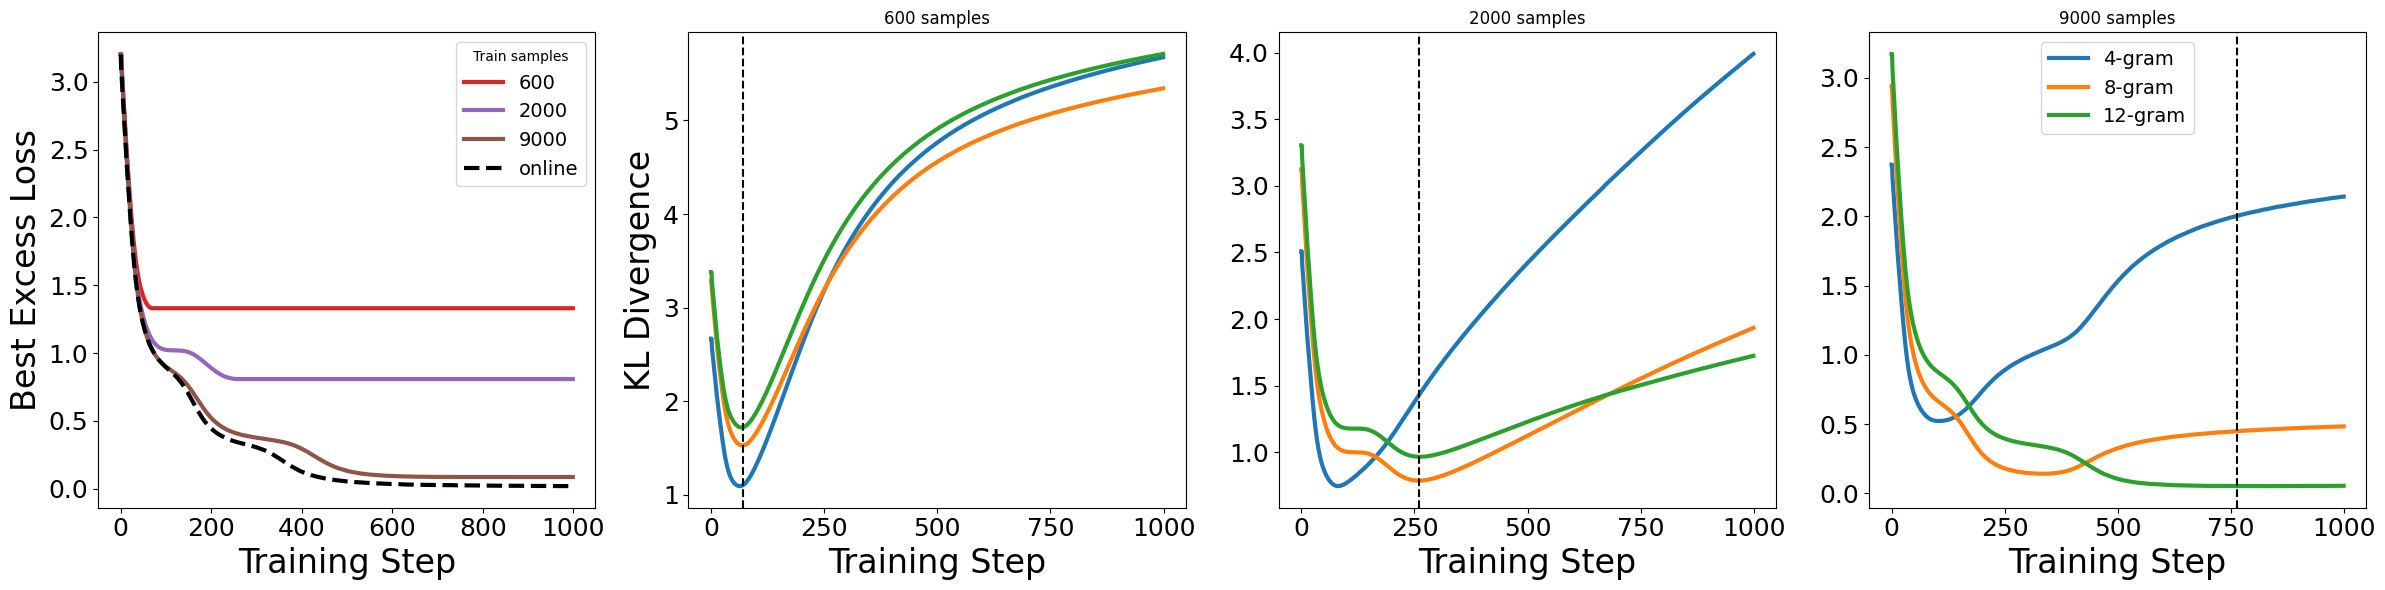

In [3]:
groups = df.groupby(["_run_name", "cfg.dataset.number.train"])[
    [
        "val_loss",
        "teacher_val_loss",
        "val_best",
        "kl_div_unigram_learned_val",
        "kl_div_bigram_learned_val",
        "kl_div_trigram_learned_val",
    ]
]
groups = sorted(groups, key=lambda item: (item[0][1] < 0, item[0][1]))

kl_selected_nums = [600, 2000, 9000]
val_selected_nums = [600, 2000, 9000, -3000]
max_step = 1000

picked = {}
for (_, num_train), data in groups:
    if num_train in kl_selected_nums and num_train not in picked:
        picked[num_train] = data

fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=False)
ax_val = axes[0]
ax_kl_list = axes[1:]

ax_val.set_prop_cycle(cycler(color=["tab:red", "tab:purple", "tab:brown"]))
val_handles, val_labels, seen = [], [], set()
for (_, num_train), data in groups:
    if num_train not in val_selected_nums:
        continue
    teacher_val_loss = data["teacher_val_loss"].dropna().unique()[0]
    y = (data["val_best"].to_numpy() - teacher_val_loss)[:max_step]
    label = "online" if num_train < 0 else str(int(num_train))
    line_style = "--" if num_train < 0 else "-"
    color = "black" if num_train < 0 else None
    (line,) = ax_val.plot(y, label=label, linewidth=REPORT_LINEWIDTH, linestyle=line_style, color=color)
    if label not in seen:
        val_handles.append(line)
        val_labels.append(label)
        seen.add(label)

style_report_axis(ax_val, xlabel="Training Step", ylabel="Best Excess Loss")
ax_val.legend(val_handles, val_labels, title="Train samples", fontsize=14, frameon=True)

kl_colors = REPORT_HEAD_COLORS
kl_labels = ["4-gram", "8-gram", "12-gram"]
for ax, num_train in zip(ax_kl_list, kl_selected_nums):
    data = picked[num_train]
    series = [
        data["kl_div_unigram_learned_val"].to_numpy()[:max_step],
        data["kl_div_bigram_learned_val"].to_numpy()[:max_step],
        data["kl_div_trigram_learned_val"].to_numpy()[:max_step],
    ]
    for y, color, label in zip(series, kl_colors, kl_labels):
        ax.plot(y, color=color, linewidth=REPORT_LINEWIDTH, label=label)

    best_step = int(np.nanargmin(data["val_best"].to_numpy()[:max_step]))
    ax.axvline(best_step, color="black", linestyle="--", linewidth=1.5)
    ax.set_title(f"{num_train} samples")
    style_report_axis(ax, xlabel="Training Step")
    ax.xaxis.set_major_locator(MultipleLocator(250))

ax_kl_list[0].set_ylabel("KL Divergence", fontsize=24)
ax_kl_list[-1].legend(fontsize=14, frameon=True)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(output_path("dataset-experiments.pdf"), bbox_inches="tight", dpi=300)
else:
    plt.show()
